In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import cv2

sys.path.append("../")

from oxels.transformation import ImagePerspectiveTransform
from oxels.datasets import PerspectiveImagesDataset

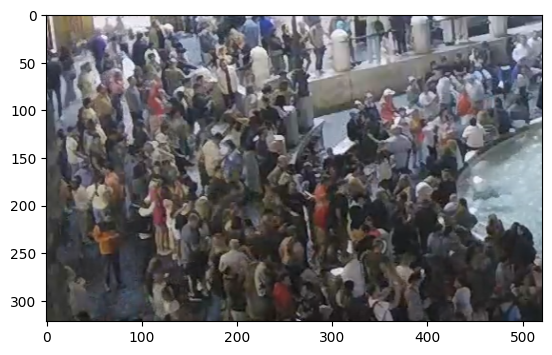

In [2]:
import glob
files = glob.glob("../../Pictures/Screenshots/*.png")

def load_image(path):
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = img_rgb.astype(np.float32) / 255.0
    return img_rgb

# Example usage
im = load_image(files[0])
plt.imshow(im)

(np.float64(-0.5), np.float64(383.5), np.float64(255.5), np.float64(-0.5))

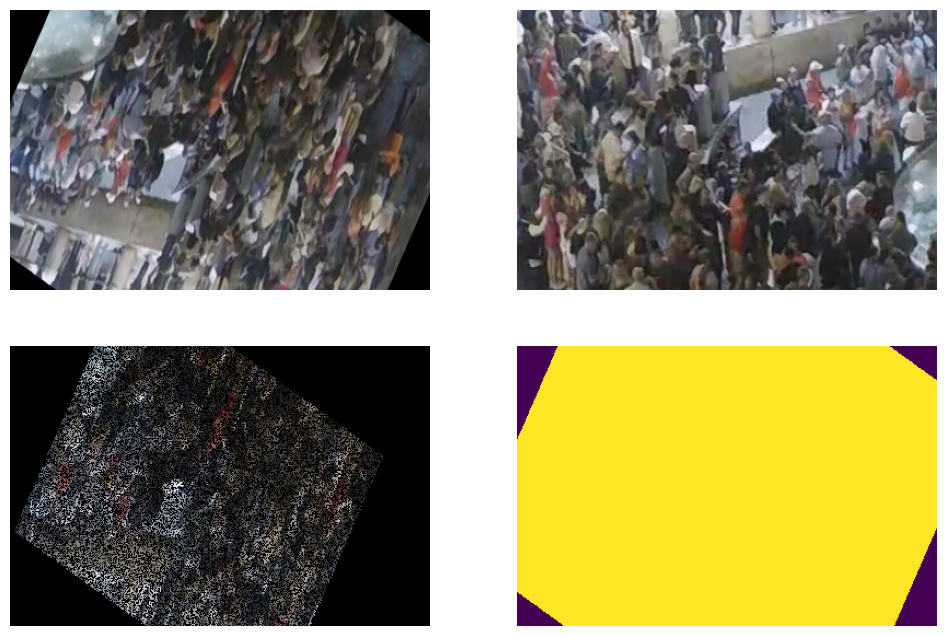

In [11]:
pv = ImagePerspectiveTransform(256+128, 256, frac_keep=0.5)
view1, view2, permutation, flags, mask1, mask2 = pv.get_views_and_permutation(im)

plt.figure(figsize=(12,8))
plt.subplot(221)
plt.imshow(view1)
plt.axis("off")
plt.subplot(222)
plt.imshow(view2)
plt.axis("off")
plt.subplot(223)
plt.imshow((view2.reshape((-1,3))[permutation]*flags[:,None]).reshape(view2.shape))
plt.axis("off")
plt.subplot(224)
plt.imshow(mask1.reshape(view1.shape[:2]))
plt.axis("off")

In [4]:
dataset = PerspectiveImagesDataset(files, lambda x: x, 256+128, 256, 0.5)

In [5]:
view1, view2, permutation, flags, _, _ = dataset._get_data(files[0])

(np.float64(-0.5), np.float64(383.5), np.float64(255.5), np.float64(-0.5))

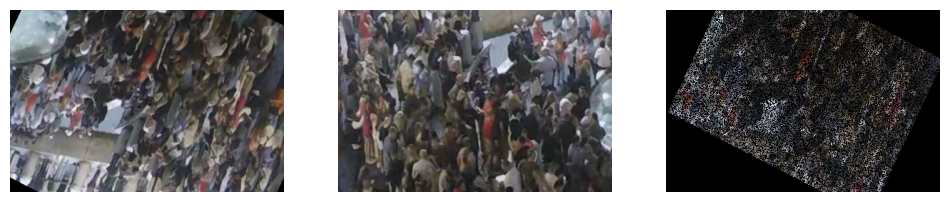

In [6]:
plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(view1)
plt.axis("off")
plt.subplot(132)
plt.imshow(view2)
plt.axis("off")
plt.subplot(133)
plt.imshow((view2.reshape((-1,3))[permutation]*flags[:,None]).reshape(view2.shape))
plt.axis("off")